# Fit Prophet model to the time dependency of cumulative sales for each store.

19:01:13 - cmdstanpy - INFO - Chain [1] start processing
19:01:13 - cmdstanpy - INFO - Chain [1] done processing
19:01:14 - cmdstanpy - INFO - Chain [1] start processing
19:01:14 - cmdstanpy - INFO - Chain [1] done processing
19:01:14 - cmdstanpy - INFO - Chain [1] start processing
19:01:14 - cmdstanpy - INFO - Chain [1] done processing
19:01:14 - cmdstanpy - INFO - Chain [1] start processing
19:01:15 - cmdstanpy - INFO - Chain [1] done processing
19:01:15 - cmdstanpy - INFO - Chain [1] start processing
19:01:15 - cmdstanpy - INFO - Chain [1] done processing
19:01:15 - cmdstanpy - INFO - Chain [1] start processing
19:01:15 - cmdstanpy - INFO - Chain [1] done processing
19:01:16 - cmdstanpy - INFO - Chain [1] start processing
19:01:16 - cmdstanpy - INFO - Chain [1] done processing
19:01:16 - cmdstanpy - INFO - Chain [1] start processing
19:01:16 - cmdstanpy - INFO - Chain [1] done processing
19:01:16 - cmdstanpy - INFO - Chain [1] start processing
19:01:17 - cmdstanpy - INFO - Chain [1]

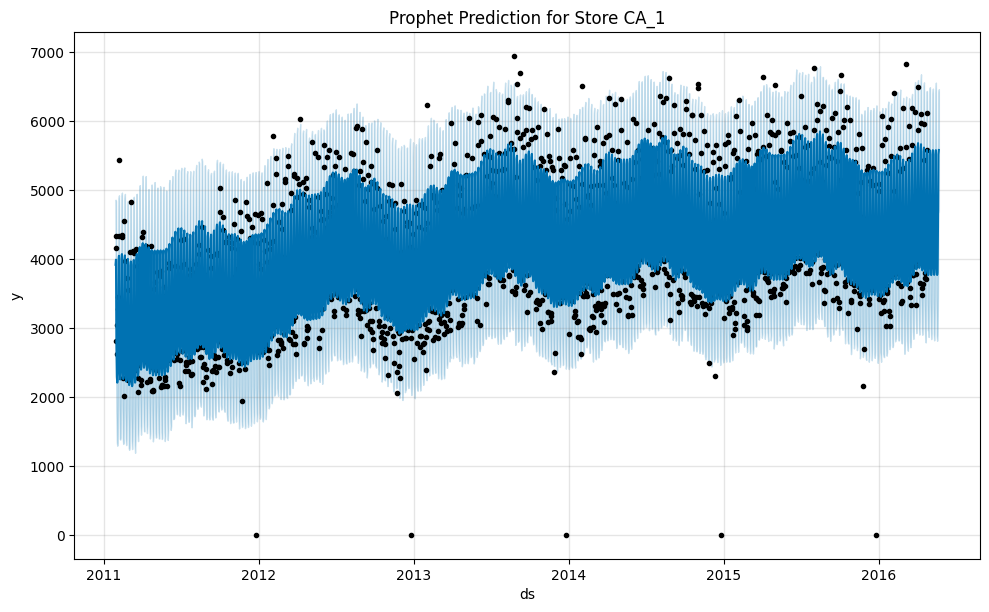

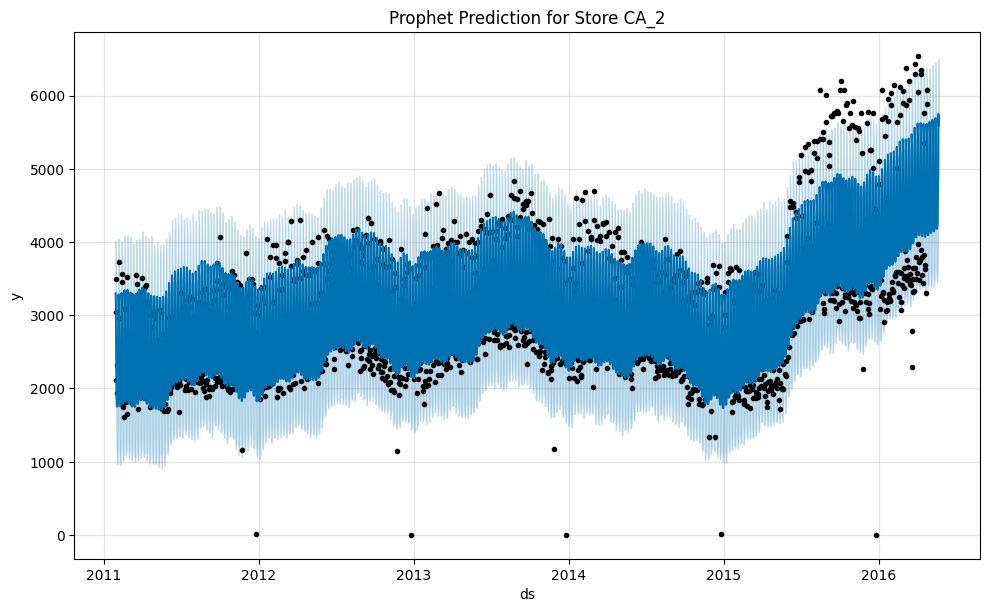

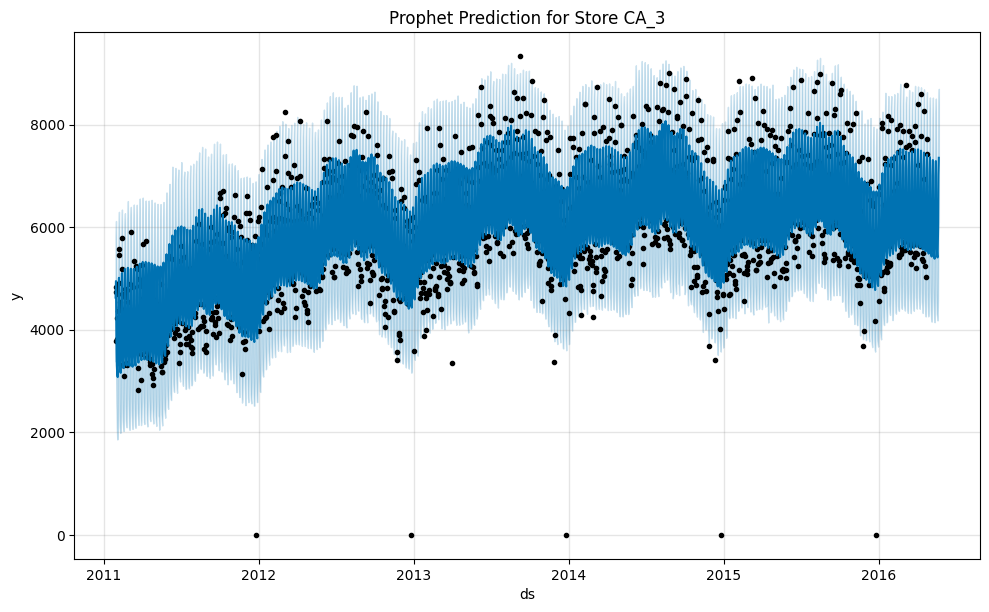

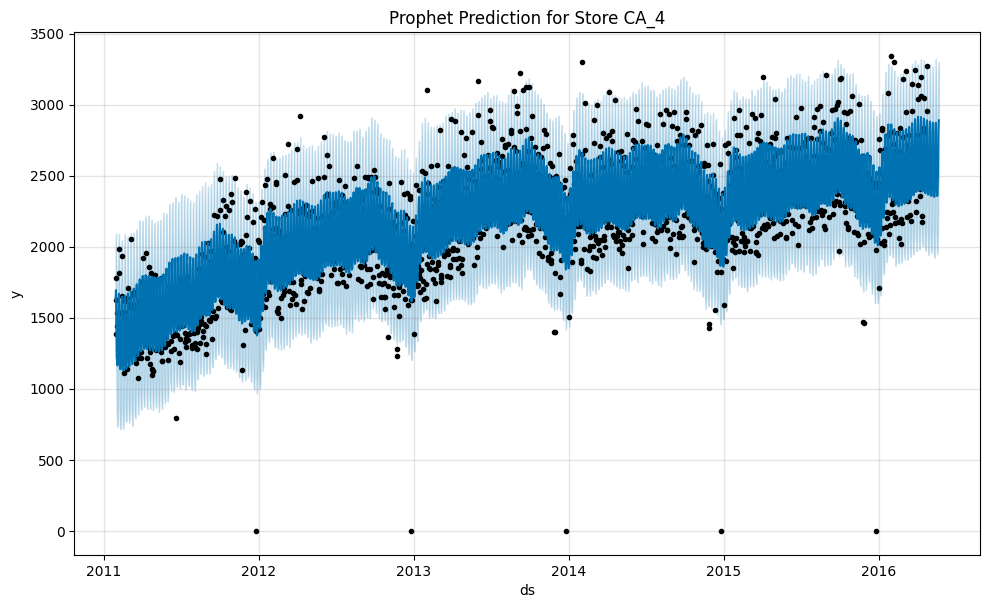

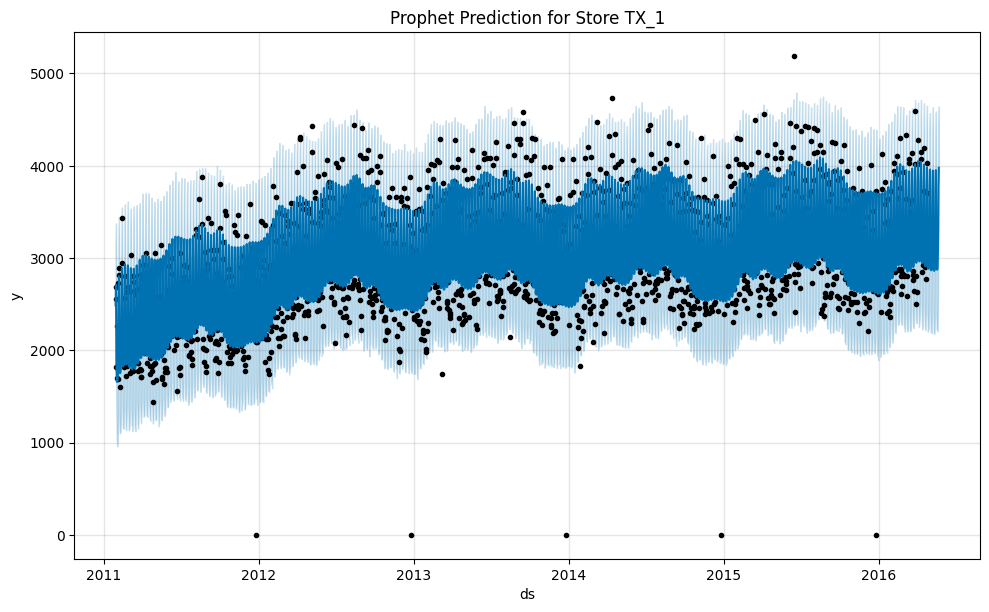

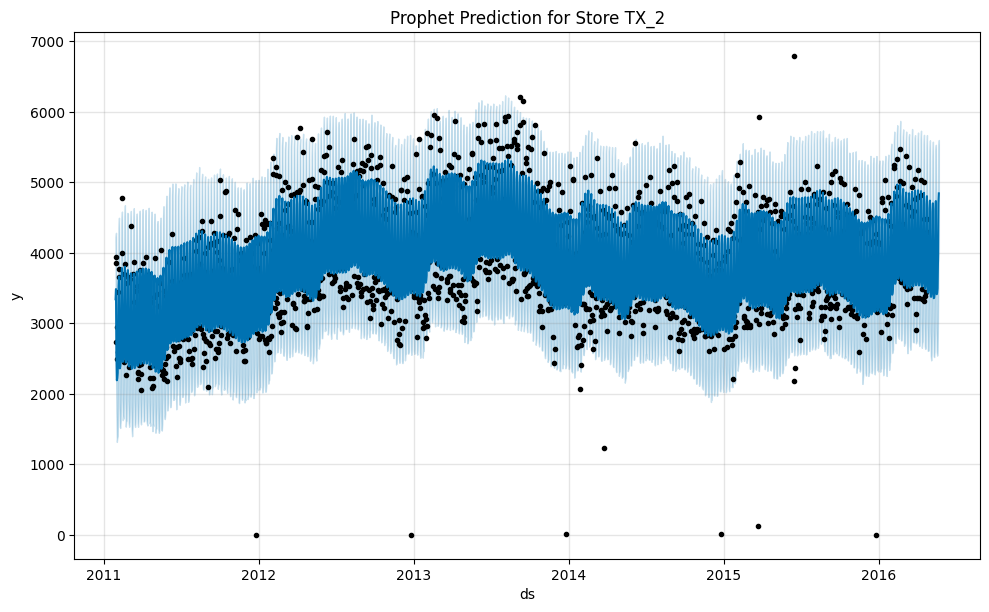

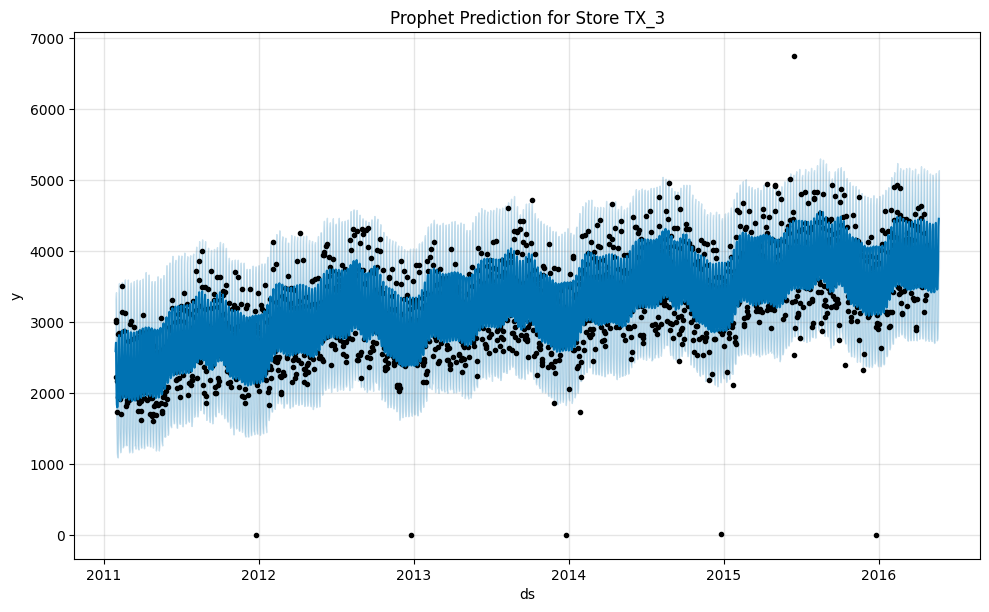

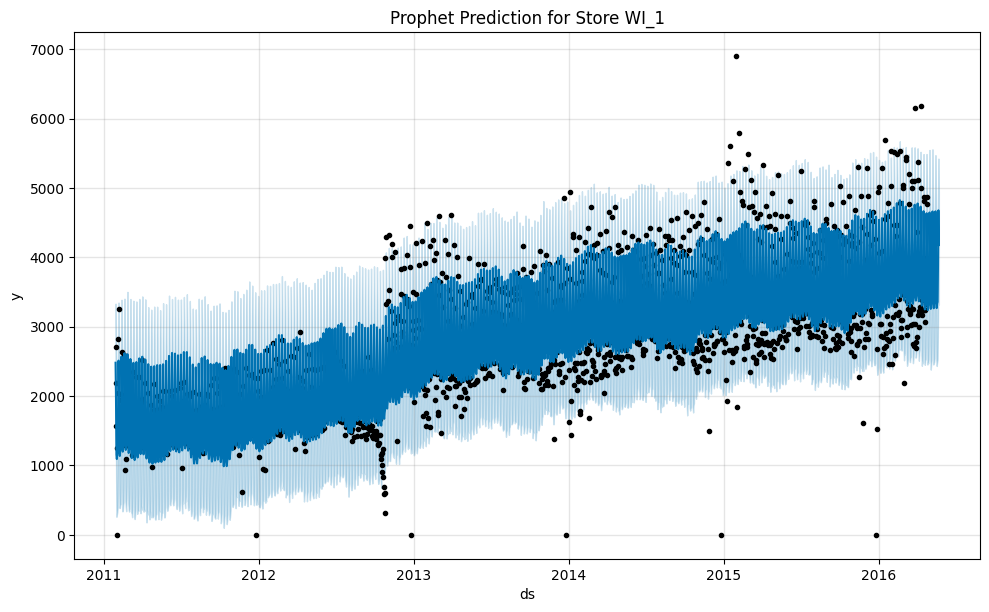

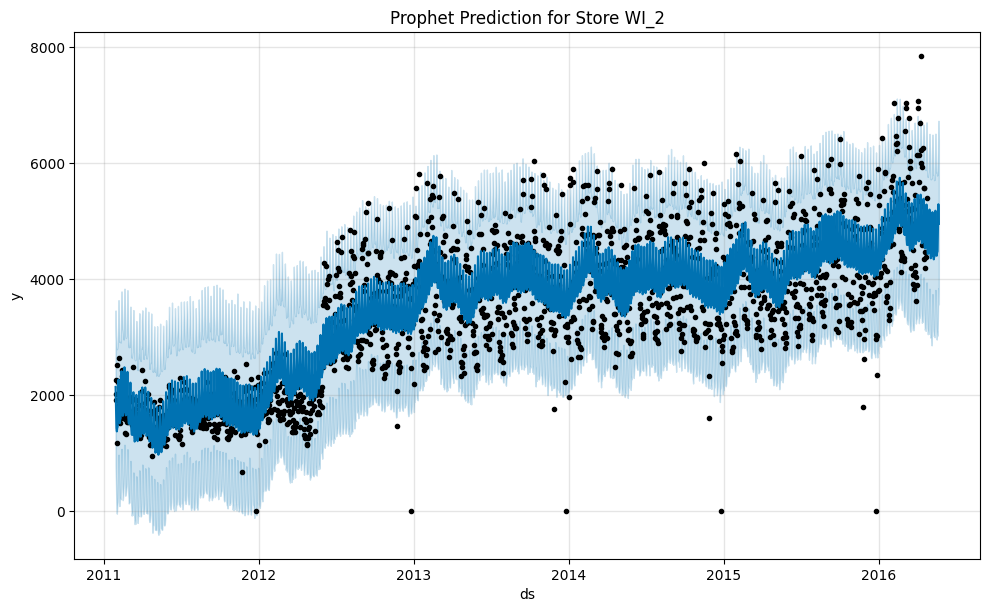

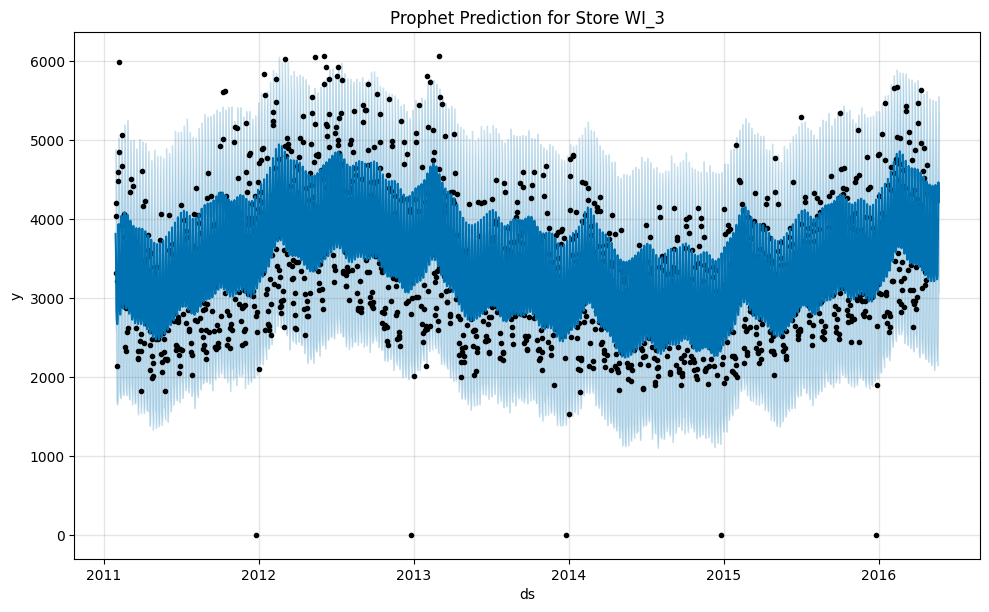

In [3]:
import os
import pandas as pd
from prophet import Prophet
import numpy as np
import matplotlib.pyplot as plt

DATASETS_PATH = os.getenv("DATASETS_PATH") 

df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")

df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")

df_sales_train = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_validation.csv")

df_sales_test = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")

store_ids = df_sales_train['store_id'].unique()

store_dfs = {}

store_sums_train = {}

store_sums_test = {}

store_sell_prices = {}

for store in store_ids:
    
    df_store_train = df_sales_train[df_sales_train['store_id'] == store].copy()
    day_cols_train = [col for col in df_store_train.columns if col.startswith('d_')]
    df_sum_train = df_store_train[day_cols_train].sum(axis=0).reset_index()
    df_sum_train.columns = ['d', 'y']
    store_sums_train[store] = df_sum_train.copy()

    df_store_test = df_sales_test[df_sales_test['store_id'] == store].copy()
    day_cols_test = [col for col in df_store_test.columns if col.startswith('d_')]
    df_sum_test = df_store_test[day_cols_test].sum(axis=0).reset_index()
    df_sum_test.columns = ['d', 'y']
    store_sums_test[store] = df_sum_test.copy()

    df_store_prices = df_sell_prices[df_sell_prices['store_id'] == store].copy()
    store_sell_prices[store] = df_store_prices.copy()
    
    
    df_prophet = df_sum_train.merge(df_calendar[['d','date']], on='d', how='left')
    
    df_prophet = df_prophet[['date','y']].rename(columns={'date':'ds'})
    
    store_dfs[store] = df_prophet.copy()
   

store_models = {} 
for store, df in store_dfs.items(): 
    model = Prophet(interval_width=0.95) 
    model.fit(df) 
    store_models[store] = model

future_days = 28

# Dictionary to store forecasts for each store
store_forecasts = {}

for store_id, df_store in store_dfs.items():
    
    # Get the trained model
    model = store_models[store_id]
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=future_days)
    
    # Predict
    forecast = model.predict(future)
    
    # Optional: plot
    fig = model.plot(forecast)
    plt.title(f"Prophet Prediction for Store {store_id}")
    plt.show()
    
    # Keep only relevant columns
    forecast_store = forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']].copy()
    
    # Add store_id column
    forecast_store['store_id'] = store_id
    
    # Save in dictionary
    store_forecasts[store_id] = forecast_store.copy()


In [4]:
print(store_forecasts)

{'CA_1':              ds   yhat_lower   yhat_upper         yhat store_id
0    2011-01-29  3070.926891  4861.565835  3917.537422     CA_1
1    2011-01-30  3138.018141  4844.258748  3991.203969     CA_1
2    2011-01-31  1772.022337  3648.285528  2725.109736     CA_1
3    2011-02-01  1342.005847  3210.720740  2290.586326     CA_1
4    2011-02-02  1292.352139  3080.880804  2207.502741     CA_1
...         ...          ...          ...          ...      ...
1936 2016-05-18  2814.997475  4711.283195  3769.626355     CA_1
1937 2016-05-19  2890.540601  4710.336224  3808.640561     CA_1
1938 2016-05-20  3466.015806  5349.101377  4471.292615     CA_1
1939 2016-05-21  4712.813979  6419.319547  5517.809955     CA_1
1940 2016-05-22  4683.313652  6465.311143  5583.489589     CA_1

[1941 rows x 5 columns], 'CA_2':              ds   yhat_lower   yhat_upper         yhat store_id
0    2011-01-29  2519.052742  4016.091150  3297.646884     CA_2
1    2011-01-30  2403.755520  3875.684705  3120.281203     CA

In [ ]:
print(store_sums_train)

In [ ]:
print(store_sums_test)

In [5]:
print(store_sell_prices)

{'CA_1':        store_id        item_id  wm_yr_wk  sell_price
0          CA_1  HOBBIES_1_001     11325        9.58
1          CA_1  HOBBIES_1_001     11326        9.58
2          CA_1  HOBBIES_1_001     11327        8.26
3          CA_1  HOBBIES_1_001     11328        8.26
4          CA_1  HOBBIES_1_001     11329        8.26
...         ...            ...       ...         ...
698407     CA_1    FOODS_3_827     11617        1.00
698408     CA_1    FOODS_3_827     11618        1.00
698409     CA_1    FOODS_3_827     11619        1.00
698410     CA_1    FOODS_3_827     11620        1.00
698411     CA_1    FOODS_3_827     11621        1.00

[698412 rows x 4 columns], 'CA_2':         store_id        item_id  wm_yr_wk  sell_price
698412      CA_2  HOBBIES_1_001     11327        8.26
698413      CA_2  HOBBIES_1_001     11328        8.26
698414      CA_2  HOBBIES_1_001     11329        8.26
698415      CA_2  HOBBIES_1_001     11330        8.26
698416      CA_2  HOBBIES_1_001     11331        

In [7]:
result_store_prices = {}
for store in store_ids:
    pivot_prices = store_sell_prices[store].pivot_table(
    index='wm_yr_wk',
    columns='item_id',
    values='sell_price',
    aggfunc='first'
    )
    # Get original item order from sales
    original_items = df_sales_train[df_sales_train['store_id'] == store]['item_id'].tolist()
    
    # Keep only unique (in case duplicates)
    original_items = list(dict.fromkeys(original_items))
    
    # Reindex pivot table
    pivot_prices = pivot_prices.reindex(columns=original_items)
    
    df_day_week = df_calendar[['d','wm_yr_wk']]
    
    result_store_prices[store] = df_day_week.merge(
        pivot_prices.reset_index(),
        on='wm_yr_wk',
        how='left'
    ).set_index('d')
    
    # Drop wm_yr_wk if needed
    result_store_prices[store] = result_store_prices[store].drop(columns='wm_yr_wk', errors='ignore')
    
    # Fill missing
    result_store_prices[store] = result_store_prices[store].fillna(0)

print(result_store_prices)

{'CA_1':         HOBBIES_1_001  HOBBIES_1_002  HOBBIES_1_003  HOBBIES_1_004  \
d                                                                    
d_1              0.00           0.00           0.00           0.00   
d_2              0.00           0.00           0.00           0.00   
d_3              0.00           0.00           0.00           0.00   
d_4              0.00           0.00           0.00           0.00   
d_5              0.00           0.00           0.00           0.00   
...               ...            ...            ...            ...   
d_1965           8.38           3.97           2.97           4.64   
d_1966           8.38           3.97           2.97           4.64   
d_1967           8.38           3.97           2.97           4.64   
d_1968           8.38           3.97           2.97           4.64   
d_1969           8.38           3.97           2.97           4.64   

        HOBBIES_1_005  HOBBIES_1_006  HOBBIES_1_007  HOBBIES_1_008  \
d         

In [8]:
day_cols = [col for col in df_sales_train.columns if col.startswith('d_')]
total_sales_per_item = (
    df_sales_train[day_cols]
    .sum(axis=1)
    .groupby(df_sales_train['item_id'])
    .sum()
)
print(total_sales_per_item)

item_id
FOODS_1_001         12247
FOODS_1_002          7334
FOODS_1_003         13394
FOODS_1_004        129481
FOODS_1_005         22914
                    ...  
HOUSEHOLD_2_512     11555
HOUSEHOLD_2_513      7916
HOUSEHOLD_2_514      3150
HOUSEHOLD_2_515      1121
HOUSEHOLD_2_516      2543
Length: 3049, dtype: int64


In [9]:
item_cat_map = df_sales_train[['item_id', 'cat_id']].drop_duplicates()
sales_with_cat = total_sales_per_item.reset_index(name='total_sales').merge(
    item_cat_map,
    on='item_id',
    how='left'
)
total_sales_per_category = (
    sales_with_cat
    .groupby('cat_id')['total_sales']
    .sum()
)
print(total_sales_per_category)

cat_id
FOODS        45089939
HOBBIES       6124800
HOUSEHOLD    14480670
Name: total_sales, dtype: int64


In [10]:
sales_with_cat['cat_total'] = sales_with_cat['cat_id'].map(total_sales_per_category)

# Compute weights
sales_with_cat['weight'] = (
    sales_with_cat['total_sales'] / sales_with_cat['cat_total']
)
weights_by_cat = {}

for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    df_cat = sales_with_cat[sales_with_cat['cat_id'] == cat]
    
    weights_by_cat[cat] = df_cat.set_index('item_id')['weight']

features_per_store = {}

df_day_week = df_calendar[['d','wm_yr_wk']]

for store in store_ids:
    price_df = result_store_prices[store]
    
    features = pd.DataFrame(index=price_df.index)
    
    for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
        
        weights = weights_by_cat[cat]
        
        # Align columns
        common_items = price_df.columns.intersection(weights.index)
        
        features[f'{cat}_price_index'] = (
            price_df[common_items] @ weights.loc[common_items]
        )
    features_per_store[store]=features.copy()

print(features_per_store)

{'CA_1':         FOODS_price_index  HOBBIES_price_index  HOUSEHOLD_price_index
d                                                                    
d_1              1.456275             1.516160               1.674497
d_2              1.456275             1.516160               1.674497
d_3              1.456275             1.516160               1.674497
d_4              1.456275             1.516160               1.674497
d_5              1.456275             1.516160               1.674497
...                   ...                  ...                    ...
d_1965           2.498240             3.751838               3.902429
d_1966           2.498240             3.751838               3.902429
d_1967           2.498240             3.751838               3.902429
d_1968           2.498341             3.749266               3.901985
d_1969           2.498341             3.749266               3.901985

[1969 rows x 3 columns], 'CA_2':         FOODS_price_index  HOBBIES_price_index 

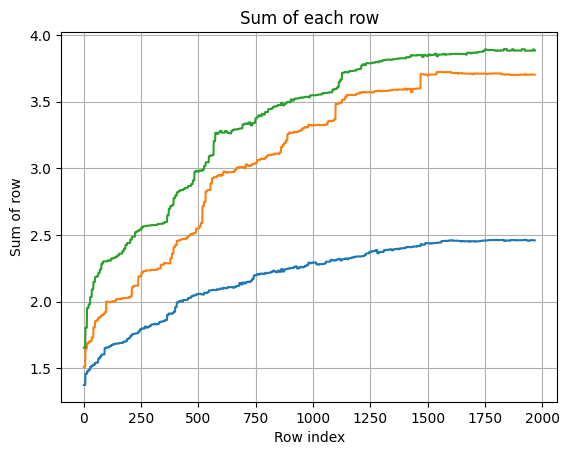

In [11]:
plt.plot(features_per_store['TX_1'].to_numpy())
plt.xlabel("Row index")
plt.ylabel("Sum of row")
plt.title("Sum of each row")
plt.grid(True)
plt.show()

In [12]:
calendar = df_calendar.copy()
calendar = calendar[[
    'date', 'd', 'wday', 'month',
    'event_name_1','event_type_1',
    'event_name_2','event_type_2',
    'snap_CA','snap_TX','snap_WI'
]]
calendar['date'] = pd.to_datetime(calendar['date'])

final_dfs = []

for store in store_ids:
    # 1. Forecast
    df_forecast = store_forecasts[store].copy()

    # 2. Price features (d-based)
    df_prices = features_per_store[store].reset_index()  # 'd' becomes column

    # 3. Actual sales (y)
    df_sales = store_sums_test[store].copy()

    # 4. Merge prices + sales
    df = df_prices.merge(df_sales, on='d', how='left')

    # 5. Merge calendar
    df = df.merge(calendar, on='d', how='left')

    # 6. Merge forecast (via date)
    df = df.merge(
        df_forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']],
        left_on='date',
        right_on='ds',
        how='left'
    )
    df.drop(columns='ds', inplace=True)

    # 7. Add store + state
    state = store.split('_')[0]
    df['state'] = state
    df['store_id'] = store

    # 8. SNAP column (state-specific)
    snap_col = f'snap_{state}'
    df['snap'] = df[snap_col]

    # 9. Select final columns
    df = df[[
        'date','wday','month',
        'event_name_1','event_type_1',
        'event_name_2','event_type_2',
        'state','store_id','snap',
        'yhat_lower','yhat_upper','yhat',
        'FOODS_price_index','HOBBIES_price_index','HOUSEHOLD_price_index',
        'y'
    ]]

    final_dfs.append(df)

# Combine all stores — now we have 1941 dates x n stores
final_df = pd.concat(final_dfs, ignore_index=True)

# Fill missing event info
final_df[['event_name_1','event_type_1','event_name_2','event_type_2']] = \
    final_df[['event_name_1','event_type_1','event_name_2','event_type_2']].fillna('None')

# -------------------------------
# Keep first 1941 dates per store for training
# -------------------------------
final_df_train = final_df.groupby('store_id').head(1941).reset_index(drop=True)

# -------------------------------
# Encode categorical features
# -------------------------------
from sklearn.preprocessing import LabelEncoder

cat_cols = ['event_name_1','event_type_1','event_name_2','event_type_2','state','store_id']
initial_features_train = final_df_train.copy()
mappings = {}
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    initial_features_train[col] = le.fit_transform(initial_features_train[col].astype(str))
    # Save the encoder
    label_encoders[col] = le
    
    # Save mapping as dictionary {original_value: encoded_value}
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# -------------------------------
# Check shapes
# -------------------------------
print("Train shape:", initial_features_train.shape)
print("Unique states:", initial_features_train['state'].unique())
print("Unique stores:", initial_features_train['store_id'].unique())
print("Unique events 2:", initial_features_train['event_type_1'].unique())
print("State mapping:", mappings['event_name_1'])
print("Store mapping:", mappings['store_id'])

Train shape: (19410, 17)
Unique states: [0 1 2]
Unique stores: [0 1 2 3 4 5 6 7 8 9]
Unique events 2: [2 4 0 1 3]
State mapping: {'Chanukah End': np.int64(0), 'Christmas': np.int64(1), 'Cinco De Mayo': np.int64(2), 'ColumbusDay': np.int64(3), 'Easter': np.int64(4), 'Eid al-Fitr': np.int64(5), 'EidAlAdha': np.int64(6), "Father's day": np.int64(7), 'Halloween': np.int64(8), 'IndependenceDay': np.int64(9), 'LaborDay': np.int64(10), 'LentStart': np.int64(11), 'LentWeek2': np.int64(12), 'MartinLutherKingDay': np.int64(13), 'MemorialDay': np.int64(14), "Mother's day": np.int64(15), 'NBAFinalsEnd': np.int64(16), 'NBAFinalsStart': np.int64(17), 'NewYear': np.int64(18), 'None': np.int64(19), 'OrthodoxChristmas': np.int64(20), 'OrthodoxEaster': np.int64(21), 'Pesach End': np.int64(22), 'PresidentsDay': np.int64(23), 'Purim End': np.int64(24), 'Ramadan starts': np.int64(25), 'StPatricksDay': np.int64(26), 'SuperBowl': np.int64(27), 'Thanksgiving': np.int64(28), 'ValentinesDay': np.int64(29), 'Vet

In [13]:
print(initial_features_train)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19405 2016-05-18     5      5            19             2             3   
19406 2016-05-19     6      5            19             2             3   
19407 2016-05-20     7      5            19             2             3   
19408 2016-05-21     1      5            19             2             3   
19409 2016-05-22     2      5            19             2             3   

       event_type_2  state  store_id  snap   yhat_lower   yhat_upper  \
0                 1      0 

In [78]:
# Copy original dataframe
features_with_future = initial_features_train.copy()

# Number of future steps
future_days = 28

future_dfs = []

for store, df_store in features_with_future.groupby('store_id', sort=False):
    df_store = df_store.copy()
    
    # Prepare dictionaries to hold shifted columns
    yhat_cols = {}
    yhatlag_cols = {}
    yhat_lower_cols = {}
    yhat_upper_cols = {}
    y_cols = {}
    ylag_cols = {}
    wday_future = {}
    month_future = {}
    event_name_1_future = {}
    
    for i in range(future_days):
        wday_future[f'wday_{i}'] = df_store['wday'].shift(-(i + 1))
        month_future[f'month_{i}'] = df_store['month'].shift(-(i + 1))
        event_name_1_future[f'event_name_1_{i}'] = df_store['event_name_1'].shift(-(i + 1))
        yhat_cols[f'yhat_{i}'] = df_store['yhat'].shift(-(i + 1))
        yhatlag_cols[f'yhatlag_{i}'] = df_store['yhat'].shift((i + 1))
        yhat_lower_cols[f'yhat_lower_{i}'] = df_store['yhat_lower'].shift(-(i + 1))
        yhat_upper_cols[f'yhat_upper_{i}'] = df_store['yhat_upper'].shift(-(i + 1))
        ylag_cols[f'ylag_{i}'] = df_store['y'].shift(i + 1)
        y_cols[f'y_{i}'] = df_store['y'].shift(-(i + 1))
    
    # Concatenate all new columns at once
    future_shifts = pd.concat([
        pd.DataFrame(wday_future),
        pd.DataFrame(month_future),
        pd.DataFrame(event_name_1_future),
        pd.DataFrame(yhatlag_cols),
        pd.DataFrame(yhat_cols),
        pd.DataFrame(yhat_lower_cols),
        pd.DataFrame(yhat_upper_cols),
        pd.DataFrame(ylag_cols),
        pd.DataFrame(y_cols)
    ], axis=1)
    
    # Join with original df_store
    df_store = pd.concat([df_store, future_shifts], axis=1)
    
    future_dfs.append(df_store)

# Concatenate all stores
features_with_future = pd.concat(future_dfs, ignore_index=True)

print(features_with_future)

            date  wday  month  event_name_1  event_type_1  event_name_2  \
0     2011-01-29     1      1            19             2             3   
1     2011-01-30     2      1            19             2             3   
2     2011-01-31     3      1            19             2             3   
3     2011-02-01     4      2            19             2             3   
4     2011-02-02     5      2            19             2             3   
...          ...   ...    ...           ...           ...           ...   
19405 2016-05-18     5      5            19             2             3   
19406 2016-05-19     6      5            19             2             3   
19407 2016-05-20     7      5            19             2             3   
19408 2016-05-21     1      5            19             2             3   
19409 2016-05-22     2      5            19             2             3   

       event_type_2  state  store_id  snap  ...    y_18    y_19    y_20  \
0                 1     

In [79]:
print(list(features_with_future.columns))


['date', 'wday', 'month', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'state', 'store_id', 'snap', 'yhat_lower', 'yhat_upper', 'yhat', 'FOODS_price_index', 'HOBBIES_price_index', 'HOUSEHOLD_price_index', 'y', 'wday_0', 'wday_1', 'wday_2', 'wday_3', 'wday_4', 'wday_5', 'wday_6', 'wday_7', 'wday_8', 'wday_9', 'wday_10', 'wday_11', 'wday_12', 'wday_13', 'wday_14', 'wday_15', 'wday_16', 'wday_17', 'wday_18', 'wday_19', 'wday_20', 'wday_21', 'wday_22', 'wday_23', 'wday_24', 'wday_25', 'wday_26', 'wday_27', 'month_0', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'month_13', 'month_14', 'month_15', 'month_16', 'month_17', 'month_18', 'month_19', 'month_20', 'month_21', 'month_22', 'month_23', 'month_24', 'month_25', 'month_26', 'month_27', 'event_name_1_0', 'event_name_1_1', 'event_name_1_2', 'event_name_1_3', 'event_name_1_4', 'event_name_1_5', 'event_name_1_6', 'event_name_1_7', 'ev

In [80]:
features_with_labels = features_with_future.copy()
features_with_labels = features_with_labels.drop('date', axis=1)

features_with_labels_train = features_with_labels.sample(frac=0.8, random_state=42)
features_with_labels_test = features_with_labels.drop(features_with_labels_train.index)

features_with_labels_train = features_with_labels_train.reset_index(drop=True)
features_with_labels_test = features_with_labels_test.reset_index(drop=True)

print(features_with_labels_train)


       wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0         7     11            19             2             3             1   
1         4      8            19             2             3             1   
2         4      1            19             2             3             1   
3         7      6            19             2             3             1   
4         2     10            19             2             3             1   
...     ...    ...           ...           ...           ...           ...   
15523     2      4            19             2             3             1   
15524     2     11            19             2             3             1   
15525     7     11            19             2             3             1   
15526     2      6            19             2             3             1   
15527     5      5            19             2             3             1   

       state  store_id  snap   yhat_lower  ...    y_18    y_19 

In [81]:
print(features_with_labels_test)

      wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0        3      2            19             2             3             1   
1        5      2            19             2             3             1   
2        7      2            19             2             3             1   
3        3      2            29             0             3             1   
4        5      2            19             2             3             1   
...    ...    ...           ...           ...           ...           ...   
3877     3      5            19             2             3             1   
3878     2      5            19             2             3             1   
3879     3      5            19             2             3             1   
3880     7      5            19             2             3             1   
3881     2      5            19             2             3             1   

      state  store_id  snap   yhat_lower  ...    y_18    y_19    y_20    y_

In [85]:
# Columns for future labels
label_cols = [f'y_{i}' for i in range(28)]

# Drop rows with NaN in any of the label columns
features_with_labels_clean = features_with_labels.dropna(subset=label_cols).reset_index(drop=True)

# Split into train/test randomly
features_train = features_with_labels_clean.sample(frac=0.8, random_state=42).reset_index(drop=True)
labels_train = features_train[label_cols]
features_train = features_train.drop(columns=label_cols)

features_test = features_with_labels_clean.drop(features_train.index).reset_index(drop=True)
labels_test = features_test[label_cols]
features_test = features_test.drop(columns=label_cols)

print(features_train)

       wday  month  event_name_1  event_type_1  event_name_2  event_type_2  \
0         6      7            19             2             3             1   
1         2      8            19             2             3             1   
2         4      7            19             2             3             1   
3         2      2            19             2             3             1   
4         5      4            19             2             3             1   
...     ...    ...           ...           ...           ...           ...   
15299     1      9            19             2             3             1   
15300     6      4            19             2             3             1   
15301     7      7            19             2             3             1   
15302     5      5            19             2             3             1   
15303     6      9            19             2             3             1   

       state  store_id  snap   yhat_lower  ...  ylag_18  ylag_1

In [86]:
print(labels_train)

          y_0     y_1     y_2     y_3     y_4     y_5     y_6     y_7     y_8  \
0      4516.0  5212.0  5023.0  3804.0  3671.0  3548.0  3636.0  3956.0  4923.0   
1      6050.0  6423.0  6059.0  6116.0  6452.0  7378.0  7026.0  7827.0  6686.0   
2      2200.0  2453.0  2356.0  2915.0  2843.0  2638.0  2406.0  2463.0  2207.0   
3      3923.0  3389.0  3784.0  3950.0  3843.0  3973.0  4675.0  3726.0  2969.0   
4      1563.0  1845.0  2270.0  2257.0  1892.0  1620.0  1809.0  1793.0  1875.0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
15299  5818.0  4073.0  3797.0  3745.0  4263.0  4920.0  6177.0  6297.0  4756.0   
15300  4293.0  4457.0  4819.0  3922.0  3423.0  3306.0  3366.0  3939.0  4577.0   
15301  4353.0  4488.0  3738.0  3435.0  3241.0  3296.0  4161.0  4838.0  4807.0   
15302  4989.0  5503.0  7060.0  8172.0  6985.0  7037.0  6436.0  6453.0  6271.0   
15303  3037.0  3658.0  3954.0  2563.0  2505.0  2418.0  2365.0  2676.0  3432.0   

          y_9  ...    y_18 

In [87]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

"""
# -------------------------
# RandomForest training (as before)
# -------------------------
rf = RandomForestRegressor(n_estimators=200, max_depth=25, random_state=42, n_jobs=-1)
rf.fit(features_train, labels_train)

labels_train_pred_rf = rf.predict(features_train)
labels_test_pred_rf = rf.predict(features_test)

# Compute RMSE %
rmse_train_rf = np.sqrt(np.mean((labels_train - labels_train_pred_rf) ** 2, axis=0))
rmse_test_rf = np.sqrt(np.mean((labels_test - labels_test_pred_rf) ** 2, axis=0))

mean_rmse_train_rf_pct = rmse_train_rf.mean() / labels_train.values.mean() * 100
mean_rmse_test_rf_pct = rmse_test_rf.mean() / labels_test.values.mean() * 100

print(f"RandomForest Train RMSE%: {mean_rmse_train_rf_pct:.2f}%")
print(f"RandomForest Test RMSE%: {mean_rmse_test_rf_pct:.2f}%")
"""

# -------------------------
# XGBoost training (one model per horizon)
# -------------------------
future_horizons = labels_train.shape[1]
xgb_models = []
labels_train_pred_xgb = np.zeros_like(labels_train)
labels_test_pred_xgb = np.zeros_like(labels_test)

for i in range(future_horizons):
    model = xgb.XGBRegressor(
        n_estimators=110,
        max_depth=12,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(features_train, labels_train.iloc[:, i])
    xgb_models.append(model)
    
    labels_train_pred_xgb[:, i] = model.predict(features_train)
    labels_test_pred_xgb[:, i] = model.predict(features_test)
    print(str(i)+' out of '+ str(future_horizons))

# Compute RMSE %
rmse_train_xgb = np.sqrt(np.mean((labels_train - labels_train_pred_xgb) ** 2, axis=0))
rmse_test_xgb = np.sqrt(np.mean((labels_test - labels_test_pred_xgb) ** 2, axis=0))

mean_rmse_train_xgb_pct = rmse_train_xgb.mean() / labels_train.values.mean() * 100
mean_rmse_test_xgb_pct = rmse_test_xgb.mean() / labels_test.values.mean() * 100

print(f"XGBoost Train RMSE%: {mean_rmse_train_xgb_pct:.2f}%")
print(f"XGBoost Test RMSE%: {mean_rmse_test_xgb_pct:.2f}%")


0 out of 28
1 out of 28
2 out of 28
3 out of 28
4 out of 28
5 out of 28
6 out of 28
7 out of 28
8 out of 28
9 out of 28
10 out of 28
11 out of 28
12 out of 28
13 out of 28
14 out of 28
15 out of 28
16 out of 28
17 out of 28
18 out of 28
19 out of 28
20 out of 28
21 out of 28
22 out of 28
23 out of 28
24 out of 28
25 out of 28
26 out of 28
27 out of 28
XGBoost Train RMSE%: 1.63%
XGBoost Test RMSE%: 5.86%
